# Python concepts

Finnish university students are encouraged to use the CSC Noppe platform.<br/>
<a href="https://noppe.csc.fi/"><img alt="CSC badge" src="https://img.shields.io/badge/launch-CSC%20Noppe-blue.svg" style="vertical-align:text-bottom"></a>

Others can follow the lesson and fill in their student notebooks using Binder.<br/>
<a href="https://mybinder.org/v2/gh/introqg/notebooks/main?urlpath=lab/tree/L2/linear-correlation.ipynb"><img alt="Binder badge" src="https://img.shields.io/badge/launch-binder-red.svg" style="vertical-align:text-bottom"></a>

Here we present a few new Python concepts that may be helpful in completing this week's exercise.

## While loops

A `while` loop is another type of loop in Python. We are already familiar with the `for` loop, which is typically used to iterate a certain number of times. In contrast, a `while` loop is used to iterate until a condition is met. The general syntax is below.

```python
while condition:
    do things
```

So, the basic idea is that as long as `condition` is true, the loop will continue running. Like a `for` loop, the statement of a `while` loop must end with a `:` character and the code that is executed in the loop must be indented beneath the `while` statement.

Let's have a look at an example.

In [1]:
names=['Moomin', 'Mt Blanc','Uncle Ismo','Helsinki']
i=0
while names[i] != 'Uncle Ismo':
    print(names[i])
    i=i+1
    

Moomin
Mt Blanc


So, what happens here? Well, first we define a Python list of names. After that, the variable `i` is set equal to zero to be able to reference the first index value in the list of names. The `while` loop here is then used to iterate over the values in the list as long as the condition `names[i] != 'Uncle Ismo'` is true. Within the loop we simply print out the current name and then add 1 to `i` in each iteration. As you can see, the loop terminates when the condition `names[i] != 'Uncle Ismo'` is false.

### When to use a while loop

It is true that a `for` loop can be used for many tasks in Python, but there are certain cases where it makes better sense to use a `while` loop. One example is when checking for convergence of a mathematical equation. 

As an example, let's look at how we can use a loop to [find the square root](https://en.wikipedia.org/wiki/Methods_of_computing_square_roots) of an input number starting from an initial guess. We will do this by iterating and estimating the square root of a number $S$ starting each iteration from the current best estimate $x_{n}$. Mathematically, the equation for estimating the square root is

$$
\Large
x_{n+1} = \frac{1}{2} \left( x_{n} + \frac{S}{x_{n}}\right)
$$

We can start with how we might normally approach this problem using a `for` loop.

In [3]:
number=12345
guess=12

for i in range(20):
    guess=0.5*(guess+number/guess)
    print(guess)
    

520.375
272.04913824165266
158.7134849538078
118.24757775656809
111.32358964466505
111.10826416186845
111.10805551373642
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405
111.1080555135405


As you can see above, the `for` loop keeps iterating for all 20 iterations, even though the estimate of the square root does not change for the last 13 iterations. If we now consider the same exercise using a `while` loop, then we end up with the following:

In [4]:
number=12345
guess=120
difference=2
counter=0

while difference>0.0001:
    guess_init=guess
    guess=0.5*(guess+number/guess)
    difference=abs(guess_init-guess)
    counter=counter+1
    print(guess)

111.4375
111.10854248457656
111.10805551460767
111.1080555135405


As you can see, fewer iterations are used in the `while` loop case because the calculation stops once the solution for estimate of the square root is no longer changing. Although it might not matter a great deal with a "light" calculation like this, saving iterations becomes important as the loop calculations become more computationally expensive.

And the code above might look a bit more complex than the `for` loop equivalent, but that is mainly because we need to track the difference between estimates of the square root to assess convergence. Also, the variable `counter` is not needed at all, but included here just to count the number of iterations.

### Iteration applied to Dodson's method

One of the tasks for this week's exercise is to create a function to estimate an effective closure temperature for different thermochronometer systems using [Dodson's method](https://doi.org/10.1007/BF00373790). In order to do this we will need to use some kind of loop because the situation is such that in order to estimate the effective closure temperature $T_{\mathrm{c}}$ we need to also estimate the characteristic time for a change in diffusivity $\tau$, which depends on $T_{\mathrm{c}}$. Since we need both values in both equations, a simple option would be to estimate the needed values using iterations and check to see when the estimated value of $T_{\mathrm{c}}$ stops changing. We can test this idea below. As a reminder, the equations for the effective closure temperature $T_{\mathrm{c}}$ and characteristic time $\tau$ are below.

$$
\large
T_{\mathrm{c}} = \frac{E_{\mathrm{a}}}{R \ln \left( A \tau D_{0} / a^{2} \right)}
$$

*Equation 1. The effective closure temperature according to Dodson's method, where $E_{\mathrm{a}}$ is the activation energy, $R$ is the universal gas constant, $A$ is a geometric factor ($A = 25$ for a sphere, $A = 27$ for a cylinder, and $A = 8.7$ for a planar sheet), $\tau$ is time for the diffusivity to decrease by a factor of 1/e, $D_{0}$ is the diffusivity at infinite temperature and $a$ is the diffusion domain (we'll assume this is the size of the mineral).*

$$
\large
\tau = -\frac{R T^{2}}{E_{\mathrm{a}} dT/dt}
$$

*Equation 2. The characteristic time for a change in diffusivity, where $dT/dt$ is the cooling rate.*

#### Pseudocode for calculating an effective closure temperature

The suggested way to handle calculating an effective closure temperature using Dodson's method is below.

1. Define the parameter values and constants
2. Define an initial guess for the closure temperature and difference in closure temperature from the previous iteration (should be large to start - perhaps 100.0)
3. As long as the difference in closure temperature is larger than some small convergence value (e.g., 0.001), iterate:

    - Store the previous closure temperature
    - Calculate $\tau$ using the old closure temperature estimate
    - Calculate a new closure temperature using the new value ot $\tau$
    - Store the change in closure temperature from the previous iteration
    
4. Convert from a closure temperature in Kelvins to degrees Celsius.

## Logarithmic scaling and plot axes

Another thing we need to be able to do for this week's exercise is to use log scaling for the plot axes. In doing this, we need to consider two factors:

1. Plotting values with a logarithmic axis
2. Distributing points where calculations are done to be equally spaced when the plot axis is logarithmic

Before talking about either of these, it may be useful to [review the meaning of a logarithm](https://en.wikipedia.org/wiki/Common_logarithm).

### Logarithmic array values

Let's start with the second point above about distributing points to be equally spaced on a log plot axis. We can investigate this by creating two NumPy arrays going from 0.01 to 100.0 either with linear (`x`) or logarithmic (`x2`) spacing between a total of 11 values. We can start with a familiar example using the NumPy `linspace()` function to create an array.

In [6]:
# Import NumPy and Matplotlib
import numpy as np
import matplotlib.pyplot as plt

As expected, the values start at 0.01 and end at 100.0 with a constant increment between them (linear scaling).

Now we can consider a second example with the same range of values, but logarithmic scaling of the increment between values. Here we will use the NumPy `logspace()` function, which will have a constant increment between the (base-10) logarithm of the array values. An important difference between the `linspace()` and `logspace()` functions is that the min and max values for the `logspace()` function should be given as the logarithm of the min/max value. For example, $\log(0.01) = -2$ and $\log(100.0) = 2$.

In [7]:
xlin=np.linspace(0.01,100,11)
xlog=np.logspace(-2,2,11)
print(xlin,xlog)

[1.0000e-02 1.0009e+01 2.0008e+01 3.0007e+01 4.0006e+01 5.0005e+01
 6.0004e+01 7.0003e+01 8.0002e+01 9.0001e+01 1.0000e+02] [1.00000000e-02 2.51188643e-02 6.30957344e-02 1.58489319e-01
 3.98107171e-01 1.00000000e+00 2.51188643e+00 6.30957344e+00
 1.58489319e+01 3.98107171e+01 1.00000000e+02]


As you can see, both arrays start and end with the same values, but the spacing (or increment) between values is different. However, this is a bit hard to compare from the array values themselves and perhaps easier to see visually.

### Logarithmic plot axes

To visualize the difference in the spacing between the points we can look at two different plots of the values. In these plots, the index of the points is on the x-axis, and the values themselves are on the y-axis. In the first case, we have linear scaling of the points on the y-axis and you can see the points of `x` are equally spaced along the y-axis whereas the points in `x2` are not.

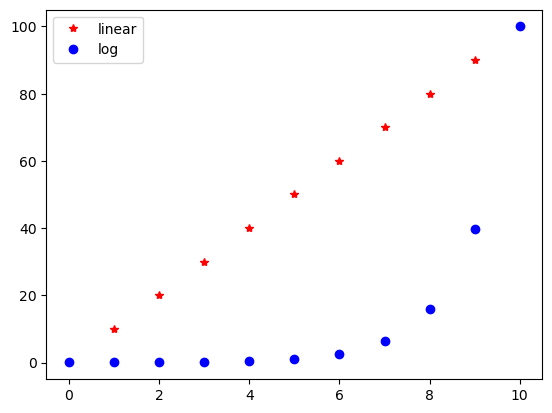

In [8]:
plt.plot(xlin,'r*',label='linear')
plt.plot(xlog,'bo',label='log')
plt.legend()

Now let's make a different version of the same plot, but set the scaling on the y-axis to be logarithmic. We can do this using the `set_yscale("log")` function.

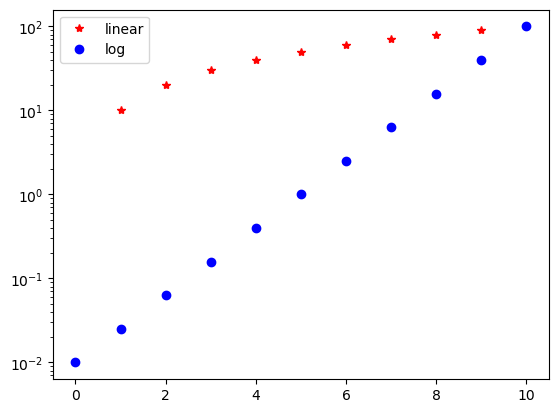

In [9]:
plt.plot(xlin,'r*',label='linear')
plt.plot(xlog,'bo',label='log')
plt.legend()
plt.yscale('log')

With a logarithmic scale for the y-axis you can see that the `x2` points are now equally spaced and those in `x` are not. This can be important to ensure your plots have good representation of all values when visualizing the data.